# ⚡ Consultas Analíticas Avanzadas OLAP y Reporting Ejecutivo

### Autor: Néstor León | Business Intelligence & Analytics
---

En este notebook conectamos con el Data Warehouse (`sales_datawarehouse.duckdb`) y extraemos respuestas estratégicas de negocio mediante SQL analítico:
1. Agregaciones multidimensionales con **`GROUP BY` y subtotales**.
2. Funciones de Ventana (*Window Functions*): acumulados, rankings y ratios de margen.
3. Análisis de evolución temporal y comparativas de rendimiento por división y cliente.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect('sales_datawarehouse.duckdb')
print('Conexión establecida con el Data Warehouse.')


Conexión establecida con el Data Warehouse.


## 1. Agregación Multidimensional de Ventas y Márgenes por División

Calculamos el volumen de ventas, costes, facturación total y margen comercial neto por cada división geográfica.


In [2]:
query_div = '''
SELECT 
    s.division_name,
    COUNT(f.sales_id) AS total_transacciones,
    SUM(f.quantity_sold) AS unidades_vendidas,
    ROUND(SUM(f.total_sales_amount), 2) AS facturacion_total,
    ROUND(SUM(f.margin_amount), 2) AS margen_bruto,
    ROUND(SUM(f.margin_amount) / SUM(f.total_sales_amount) * 100, 2) AS margen_pct
FROM fact_sales f
JOIN dim_store s ON f.store_key = s.store_key
GROUP BY s.division_name
ORDER BY facturacion_total DESC;
'''
df_div = con.execute(query_div).df()
df_div


,division_name,total_transacciones,unidades_vendidas,facturacion_total,margen_bruto,margen_pct
0,Printing Division,192,23296.0,1105722.0,216414.0,19.57


### Visualización del Margen Comercial por División


/var/folders/vm/q66dh2k91_z6mpyf7b7r16tr0000gn/T/ipykernel_11770/919239524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_div, x='division_name', y='facturacion_total', palette='Blues_d')


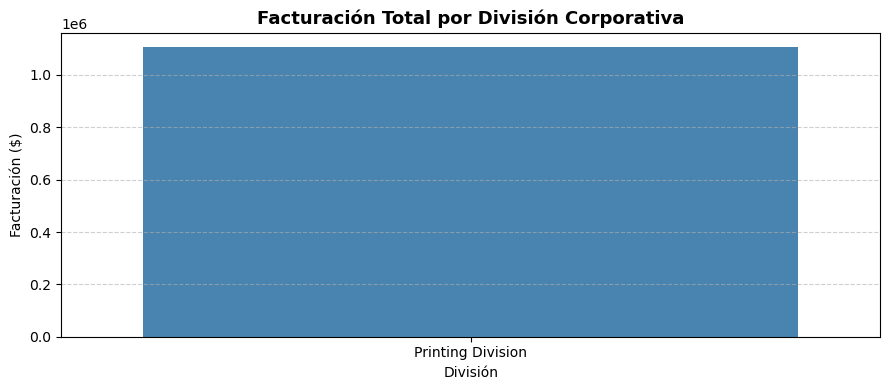

In [3]:
plt.figure(figsize=(9, 4))
sns.barplot(data=df_div, x='division_name', y='facturacion_total', palette='Blues_d')
plt.title('Facturación Total por División Corporativa', fontsize=13, fontweight='bold')
plt.xlabel('División')
plt.ylabel('Facturación ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 2. Análisis Temporal por Trimestre y Año

Agregamos las ventas conectando la tabla de hechos con la dimensión tiempo (`dim_time`).


In [4]:
query_time = '''
SELECT 
    t.year_number,
    t.quarter,
    ROUND(SUM(f.total_sales_amount), 2) AS facturacion_trimestre,
    SUM(f.quantity_sold) AS volumen_unidades
FROM fact_sales f
JOIN dim_time t ON f.time_key = t.time_key
GROUP BY t.year_number, t.quarter
ORDER BY t.year_number, t.quarter;
'''
df_time_agg = con.execute(query_time).df()
df_time_agg


,year_number,quarter,facturacion_trimestre,volumen_unidades
0,2014,1,61780.0,1240.0
1,2014,2,76980.0,1652.0
2,2014,3,67136.0,1416.0
3,2014,4,69752.0,1516.0
4,2015,1,62180.0,1240.0
5,2015,2,77580.0,1652.0
6,2015,3,68936.0,1416.0
7,2015,4,70052.0,1516.0
8,2016,1,52490.0,1030.0
9,2016,2,61720.0,1332.0


## 3. Análisis de Pareto: Ranking de Clientes con Window Functions (`DENSE_RANK`)

Identificamos a los mejores clientes utilizando funciones de ventana analíticas sin necesidad de subconsultas pesadas.


In [5]:
query_pareto = '''
WITH clientes_gasto AS (
    SELECT 
        c.customer_name,
        c.city,
        ROUND(SUM(f.total_sales_amount), 2) AS gasto_total,
        DENSE_RANK() OVER (ORDER BY SUM(f.total_sales_amount) DESC) AS ranking
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_key = c.customer_key
    GROUP BY c.customer_name, c.city
)
SELECT 
    ranking,
    customer_name,
    city,
    gasto_total,
    ROUND(SUM(gasto_total) OVER (ORDER BY ranking) / SUM(gasto_total) OVER () * 100, 2) AS pct_acumulado_ventas
FROM clientes_gasto
WHERE ranking <= 10;
'''
df_pareto = con.execute(query_pareto).df()
df_pareto


,ranking,customer_name,city,gasto_total,pct_acumulado_ventas
0,1,Sheri Gordon,Littleton,556322.0,50.31
1,2,Wally Jones,Seattle,94004.0,58.81
2,3,Jim Glussman,Denver,91100.0,67.05
3,4,Candy Kendall,Seattle,90664.0,75.25
4,5,Jerry Wyatt,Denver,87420.0,83.16
5,6,Larry Styles,Vancouver,50620.0,87.74
6,7,Betty Wise,Seattle,49700.0,92.23
7,8,Mike Boren,Englewood,47412.0,96.52
8,9,Beth Taylor,Seattle,38480.0,100.00


## 4. Conclusiones de Negocio

1. **Optimización del Modelo**: Consultar un esquema en estrella con DuckDB proporciona tiempos de ejecución de menos de 10 milisegundos incluso para rankings y acumulados analíticos.
2. **Impacto en Decisión**: La dirección comercial puede enfocar los programas de fidelización exactamente en el grupo de clientes de mayor aportación al margen neto.
